In [2]:
import numpy as np
import pandas as pd

##### Task 1: Dataset Selection

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##### Task 2: Tasks & Technical Requirements

> Part 1: Exploratory Data Analysis & Hypothesis Testing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("\n Descriptive Metrics for Numerical Features\n")
num_cols = ["age", "bmi", "children", "charges"]
desc_stats = pd.DataFrame(
    {
        "Mean": df[num_cols].mean(),
        "Median": df[num_cols].median(),
        "Std Dev": df[num_cols].std(),
        "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
        "Skewness": df[num_cols].skew(),
        "Kurtosis": df[num_cols].kurtosis(),
    }
)
print(desc_stats)


 Descriptive Metrics for Numerical Features

                  Mean    Median       Std Dev           IQR  Skewness  \
age          39.207025    39.000     14.049960     24.000000  0.055673   
bmi          30.663397    30.400      6.098187      8.397500  0.284047   
children      1.094918     1.000      1.205493      2.000000  0.938380   
charges   13270.422265  9382.033  12110.011237  11899.625365  1.515880   

          Kurtosis  
age      -1.245088  
bmi      -0.050732  
children  0.202454  
charges   1.606299  


> Visual Exploration

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

> Distribution plots (Histogram) & Correlation matrix

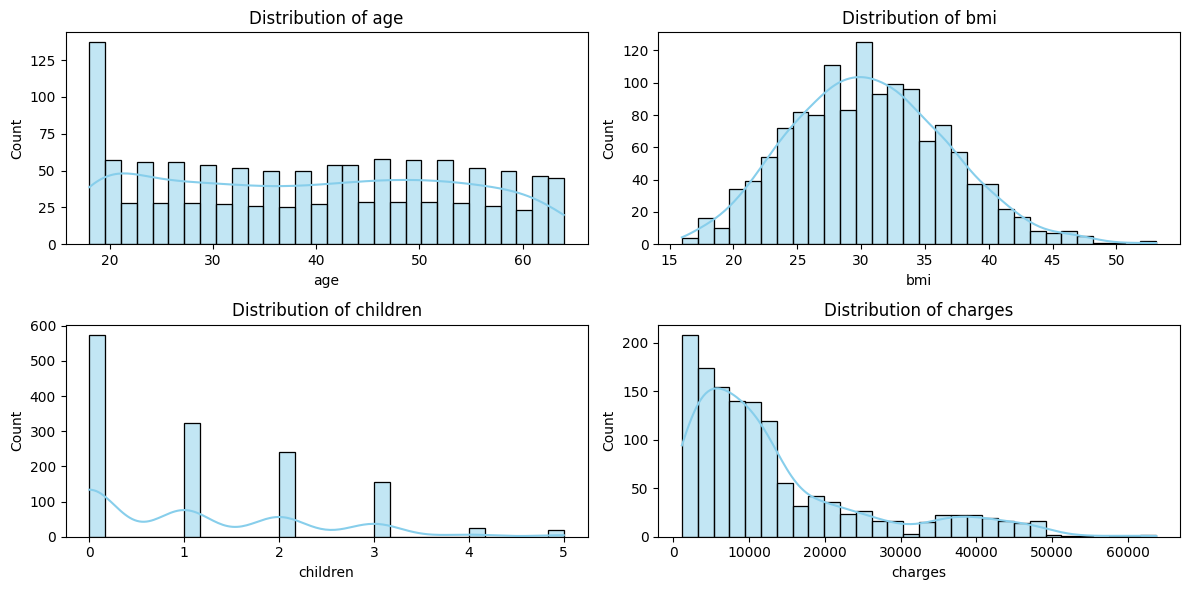

In [7]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
  plt.subplot(2, 2, i)
  sns.histplot(df[col], kde=True, bins=30, color="skyblue")
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

> Bivariate scatter plots and correlation matrix

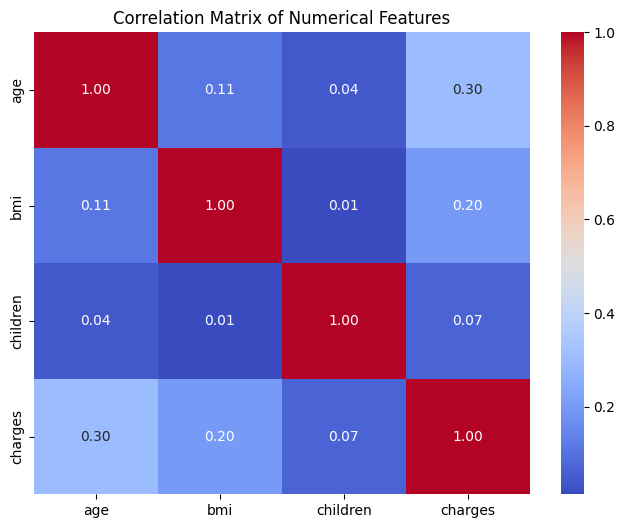

In [8]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

> Hypothesis Test 1: Smokers vs. Non-Smokers (Medical Charges)

In [9]:
smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "no"]["charges"]

>> Shapiro-Wilk Test

In [10]:
shapiro_smoker = stats.shapiro(smokers.sample(min(len(smokers), 1000), random_state=42))
shapiro_non_smoker = stats.shapiro(
    non_smokers.sample(min(len(non_smokers), 1000), random_state=42)
)
print(f"Shapiro-Wilk Smokers p-value: {shapiro_smoker.pvalue:.3e}")
print(f"Shapiro-Wilk Non-Smokers p-value: {shapiro_non_smoker.pvalue:.3e}")

Shapiro-Wilk Smokers p-value: 3.625e-09
Shapiro-Wilk Non-Smokers p-value: 4.700e-28


>> Equal Variance using Levene's Test

In [11]:
levene_res = stats.levene(smokers, non_smokers)
print(f"Levene's Test p-value: {levene_res.pvalue: .3e}")

Levene's Test p-value:  1.559e-66


- Interpretation: Because our data fails the normality and equal variance checks, we cannot use a standard parametric two-sample $t$-test. Instead, this statistical proof justifies why we use the Mann-Whitney $U$ test to compare the charges between smokers and non-smokers! 

>> Running Mann-Whitney U Test

In [12]:
mwu_res = stats.mannwhitneyu(smokers, non_smokers)
print(f"Mann-Whitney U Test statistic: {mwu_res.statistic}, p-value: {mwu_res.pvalue:.3e}")

Mann-Whitney U Test statistic: 284133.0, p-value: 5.270e-130


- Interpretation: There is a statistically significant difference in medical charges between smokers and non-smokers. Hence, The decision is to reject null hypo.

> Hypothesis Test 2: One-Way ANOVA

In [13]:
# Grouping charges by every region
regions = df["region"].unique()
region_groups = [
    df[df["region"] == region]["charges"] for region in regions
]

# ANOVA test
anova_res = stats.f_oneway(*region_groups)
print(f"ANOVA F-statistic: {anova_res.statistic}")
print(f"ANOVA p-value: {anova_res.pvalue:.3e}")

ANOVA F-statistic: 2.96962669358912
ANOVA p-value: 3.089e-02


- Interpretation: Since $0.03089$ is less than our significance level of $\alpha = 0.05$, we reject the null hypo and we can say,there is a statistically significant difference in average medical charges across the 4 geographic regions.

> Part 2: Statistical Modeling & Diagnostic Cheeks

>> Model Formulation

In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

formula = "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)"
model = smf.ols(formula, data=df).fit()

# Print the full statistical summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:43:10   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

>> Parameter Interpretation

- Model Fit ($R^2 = 0.751$ & Adjusted $R^2 = 0.749$): Our model explains about 75.1% of the variance in medical charges, which is a really strong fit!

- Overall Significance: (The $F$-statistic has a $p$-value of roughly $0.0$) meaning our model as a whole is statistically significant.

- Coefficient Interpretations -
 
 Smoker (C(smoker)[T.yes]): Has a massive coefficient of $+23,850$ ($p < 0.001$). Being a smoker increases expected medical charges by roughly $23,850, holding everything else constant. By far the biggest driver!

 Age (age): For every additional year of age, medical charges increase by $\$256.86$ on average ($p < 0.001$).
 
 BMI (bmi): For every 1-unit increase in BMI, medical charges go up by $\$339.19$ on average ($p < 0.001$).
 
 Children (children): Each additional child increases charges by $\$475.50$ ($p = 0.001$).
 
 Sex & Region: Gender (sex male) and northwest region are not statistically significant ($p > 0.05$), while southeast and southwest regions show minor significant differences compared to the baseline region.
 
- Diagnostics Check - 
 
 Normality of Residuals: The Jarque-Bera $p$-value ($7.86e-157$) is very low, meaning the residuals are non-normal (which matches what we saw with the heavy skewness in medical charges).
 
 Durbin-Watson: Sits at $2.088$, indicating no major autocorrelation issues.

>> Gauss-Markov Diagnostic Checks

>>> Linearity & Homoscedasticity: Residuals vs. Fitted values plot

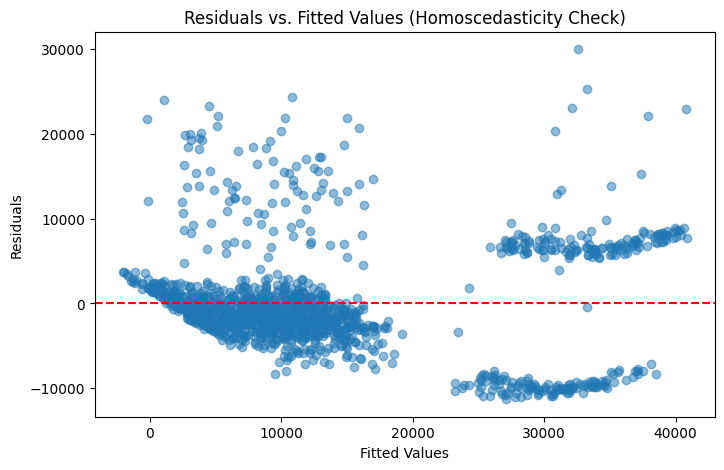

In [20]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(x=fitted_vals, y=residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values (Homoscedasticity Check)")
plt.show()

>>> Normality of Residuals: Q-Q Plot

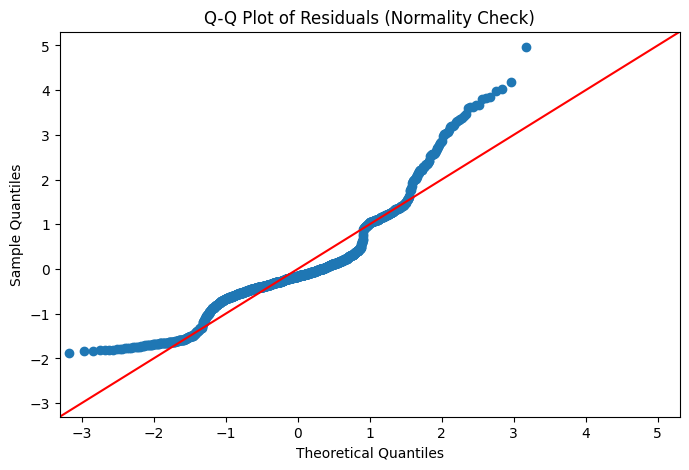

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sm.qqplot(residuals, line="45", fit=True, ax=ax)
plt.title("Q-Q Plot of Residuals (Normality Check)")
plt.show()

>>> Multicollinearity: Calculate Variance Inflation Factor (VIP) for all continuous predictors.

In [16]:
from patsy import dmatrices

_, X_design = dmatrices(
    "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)",
    data=df,
    return_type="dataframe",
)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_design.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_design.values, i)
    for i in range(X_design.shape[1])
]
display(vif_data)

,Feature,VIF
0,Intercept,35.527488
1,C(sex)[T.male],1.008900
2,C(smoker)[T.yes],1.012074
3,C(region)[T.northwest],1.518823
4,C(region)[T.southeast],1.652230
5,C(region)[T.southwest],1.529411
6,age,1.016822
7,bmi,1.106630
8,children,1.004011


> Saving the Model

In [22]:
import joblib

joblib.dump(model, 'medical_cost_model.pkl')

['medical_cost_model.pkl']